In [1]:
import rioxarray
import xarray as xr
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import glob
from pyproj import CRS#, Transformer

In [20]:
file = '/scratch/cmt/FCIL1HRFI_20250326T074107Z_20250326T074726Z_epct_ae3ffc0b_FC.tif'

In [21]:
with open("/prj/nflics/MTG_vis_testbed/crs_proj_geostationary_MTG.txt", "r") as f:
    crs = CRS.from_proj4(f.read())
def read_geotiff(file):
    data = rioxarray.open_rasterio(file)
    data_rio = data.rio.write_crs(crs)
    data_reprojected = data_rio.rio.reproject("EPSG:4326")

    # toggle to set missing data to 0 or not
    #data_reprojected = data_reprojected.where(data_reprojected.values<60000, other=0)
    
    
    return data_reprojected.squeeze()

In [22]:
da_box = read_geotiff(file)

In [23]:
### CODE TO SAVE INITIAL PROJECTION
# # Use rioxarray to interpret CRS
# data_rio = da_tif.rio.write_crs(da['geostationary'].attrs['crs_wkt'])

# # Check the CRS
# print(data_rio.rio.crs)

# # Reproject to WGS84 (EPSG:4326) if necessary
# data_reprojected = data_rio.rio.reproject("EPSG:4326")

# # Save as PROJ String
# with open("/home/ck/DIR/cornkle/data/EUMDAC_MTG_TESTS/domain_tifs/crs_proj_geostationary_MTG.txt", "w") as f:
#     f.write(data_rio.rio.crs.to_proj4())

/users/global/cornkle/miniconda3/envs/minimal/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


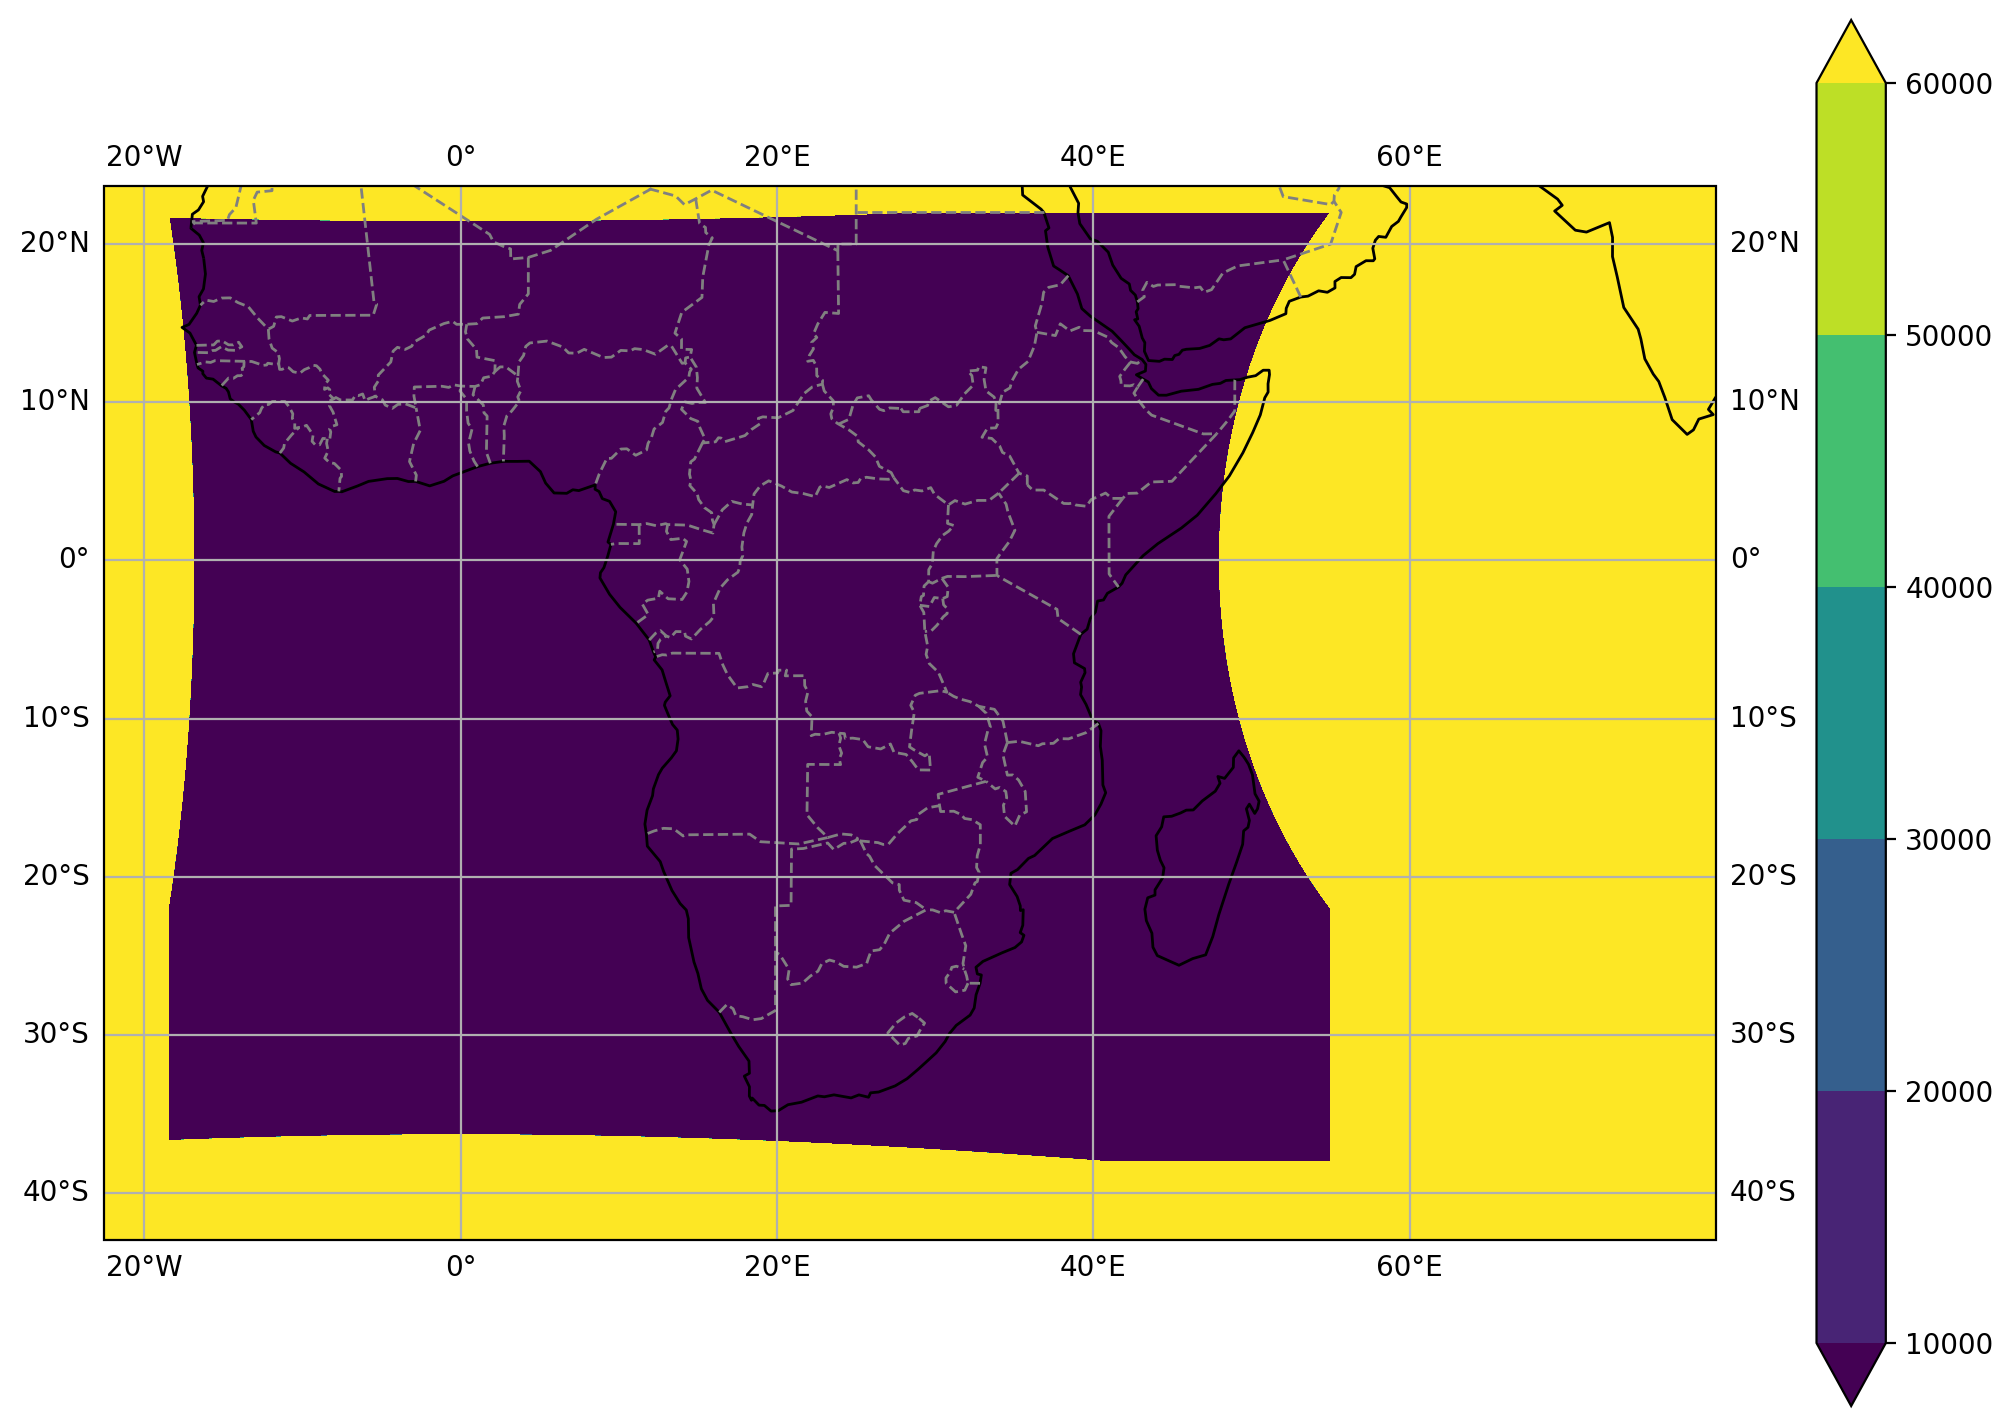

In [24]:
f = plt.figure(figsize=(13,9), dpi=200)
ax = f.add_subplot(111, projection=ccrs.PlateCarree())
plt.contourf(da_box.x.values, da_box.y.values, da_box, transform=ccrs.PlateCarree(), cmap='viridis', extend='both')
ax.coastlines()

xl = ax.gridlines(draw_labels=True);

# Countries
ax.add_feature(cartopy.feature.BORDERS, linestyle='--', color='grey');

cbar = plt.colorbar()

plt.tight_layout

f.savefig('/scratch/cmt/vis_view.jpg')